In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import os
import pickle
import sys
import optuna
import pandas as pd
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from utils import process_data_model_1, process_data_model_2, preprocess_lightgbm, get_model_metrics, get_model_figs
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from atow_estimation.paths import PROCESSED_DATA_DIR

In [10]:
data_m1 = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m1.csv"))
data_m2 = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2.csv"))
data_H = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_H.csv"))
data_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_M.csv"))
data_m1_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m1_M.csv"))
data_m1_H = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m1_H.csv"))
data_m2_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2_M.csv"))
data_m2_H = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2_H.csv"))


In [16]:
categorical_variables = [
        "routeType",
        "flightType",
        "RECATwake",
        "numberOfEngines",
        "aircraftType",
        "airlineCode",
    ]

### Model 1

In [6]:
data_1 = process_data_model_1(data)
X_train, X_test, y_train, y_test = preprocess_lightgbm(data_1)

Rows with nan features dropped: 92


In [7]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'objective': 'regression',
        'metric': 'rmse',
        'n_jobs': -1,
        'device': 'cpu',
        'random_state': 42,
        'verbosity': -1
    }
    
    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
    test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_variables, free_raw_data=False)
  
    model = lgb.train(
        params,
        train_data,
        valid_sets=[test_data],
        valid_names=['valid'],
        num_boost_round=10_000,
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(period=100)
        ]
    )    
    
    return model.best_score['valid']['rmse']    

In [8]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
best_params = study.best_params
best_rmse = study.best_value

fixed_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'n_jobs': -1,
    'device': 'cpu',
    'random_state': 42,
}
final_params = {**best_params, **fixed_params}

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_variables, free_raw_data=False)

model = lgb.train(
    final_params,
    train_data,
    valid_sets=[test_data],
    valid_names=['valid'],
    num_boost_round=10000,
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100)
    ]
)

y_pred = model.predict(X_test)

[I 2025-05-19 10:13:12,841] A new study created in memory with name: no-name-b05a68a2-5fa5-44ee-980d-7270556c1ef1


Training until validation scores don't improve for 50 rounds
[100]	valid's rmse: 7468.89
[200]	valid's rmse: 3200.32
[300]	valid's rmse: 2778.99
[400]	valid's rmse: 2678.81
[500]	valid's rmse: 2608.59
[600]	valid's rmse: 2560.46
[700]	valid's rmse: 2529.46
[800]	valid's rmse: 2505.56
[900]	valid's rmse: 2488.15
[1000]	valid's rmse: 2479.16
[1100]	valid's rmse: 2470.13
[1200]	valid's rmse: 2461.72
[1300]	valid's rmse: 2452.81
[1400]	valid's rmse: 2446.08
[1500]	valid's rmse: 2440.43
[1600]	valid's rmse: 2435.4
[1700]	valid's rmse: 2430.33
[1800]	valid's rmse: 2426.8
[1900]	valid's rmse: 2423.56
[2000]	valid's rmse: 2420.5
[2100]	valid's rmse: 2417.66
[2200]	valid's rmse: 2416.88
[2300]	valid's rmse: 2414.12
[2400]	valid's rmse: 2412.57
[2500]	valid's rmse: 2411.54
[2600]	valid's rmse: 2410.31
[2700]	valid's rmse: 2409.01
[2800]	valid's rmse: 2407.06
[2900]	valid's rmse: 2404.82
[3000]	valid's rmse: 2403.13
[3100]	valid's rmse: 2401.28
[3200]	valid's rmse: 2400.32
Early stopping, best it

[I 2025-05-19 10:14:00,469] Trial 0 finished with value: 2400.0768565029202 and parameters: {'learning_rate': 0.01643430312967667, 'num_leaves': 146, 'max_depth': 8, 'min_child_weight': 3, 'min_data_in_leaf': 58, 'reg_alpha': 0.12348180951652477, 'reg_lambda': 0.012315363264869999, 'colsample_bytree': 0.9353104348050171, 'subsample': 0.847660245182654}. Best is trial 0 with value: 2400.0768565029202.


Training until validation scores don't improve for 50 rounds
[100]	valid's rmse: 7216.82
[200]	valid's rmse: 3418.44
[300]	valid's rmse: 3038.37
[400]	valid's rmse: 2907.02
[500]	valid's rmse: 2813.45
[600]	valid's rmse: 2744.11
[700]	valid's rmse: 2699.95
[800]	valid's rmse: 2664.1
[900]	valid's rmse: 2629.79
[1000]	valid's rmse: 2601.94
[1100]	valid's rmse: 2578.37
[1200]	valid's rmse: 2561.02
[1300]	valid's rmse: 2547.9
[1400]	valid's rmse: 2533.88
[1500]	valid's rmse: 2520.13
[1600]	valid's rmse: 2504.15
[1700]	valid's rmse: 2493.08
[1800]	valid's rmse: 2481.44
[1900]	valid's rmse: 2473.27
[2000]	valid's rmse: 2464.06
[2100]	valid's rmse: 2457.47
[2200]	valid's rmse: 2451.16
[2300]	valid's rmse: 2445.85
[2400]	valid's rmse: 2438.47
[2500]	valid's rmse: 2431.53
[2600]	valid's rmse: 2425.75
[2700]	valid's rmse: 2421.77
[2800]	valid's rmse: 2416.07
[2900]	valid's rmse: 2410.34
[3000]	valid's rmse: 2406.49
[3100]	valid's rmse: 2402.51
[3200]	valid's rmse: 2398.54
[3300]	valid's rmse: 2

[I 2025-05-19 10:14:39,674] Trial 1 finished with value: 2379.8952259014486 and parameters: {'learning_rate': 0.017270968782446716, 'num_leaves': 120, 'max_depth': 5, 'min_child_weight': 2, 'min_data_in_leaf': 94, 'reg_alpha': 0.001057787856366438, 'reg_lambda': 0.006537630087101444, 'colsample_bytree': 0.8920457997978306, 'subsample': 0.6871338756982728}. Best is trial 1 with value: 2379.8952259014486.


...

Training until validation scores don't improve for 50 rounds
[100]	valid's rmse: 8027.49
[200]	valid's rmse: 3520.48
[300]	valid's rmse: 2967.86
[400]	valid's rmse: 2808.54
[500]	valid's rmse: 2720.09
[600]	valid's rmse: 2663.13
[700]	valid's rmse: 2622.41
[800]	valid's rmse: 2591.45
[900]	valid's rmse: 2563.16
[1000]	valid's rmse: 2540.45
[1100]	valid's rmse: 2523.46
[1200]	valid's rmse: 2506.07
[1300]	valid's rmse: 2491.18
[1400]	valid's rmse: 2479.36
[1500]	valid's rmse: 2469.97
[1600]	valid's rmse: 2458.74
[1700]	valid's rmse: 2448.59
[1800]	valid's rmse: 2440.54
[1900]	valid's rmse: 2433.46
[2000]	valid's rmse: 2427.59
[2100]	valid's rmse: 2421.39
[2200]	valid's rmse: 2414.04
[2300]	valid's rmse: 2409.23
[2400]	valid's rmse: 2405.76
[2500]	valid's rmse: 2401.41
[2600]	valid's rmse: 2397.36
[2700]	valid's rmse: 2392.39
[2800]	valid's rmse: 2388.09
[2900]	valid's rmse: 2384.91
[3000]	valid's rmse: 2381.27
[3100]	valid's rmse: 2378.75
[3200]	valid's rmse: 2376.44
[3300]	valid's rmse:

[I 2025-05-19 10:34:01,737] Trial 48 finished with value: 2353.129232485365 and parameters: {'learning_rate': 0.015889265578863526, 'num_leaves': 72, 'max_depth': 5, 'min_child_weight': 3, 'min_data_in_leaf': 40, 'reg_alpha': 0.07563205073408931, 'reg_lambda': 0.019915036172350638, 'colsample_bytree': 0.6811380777666735, 'subsample': 0.8571018056468646}. Best is trial 27 with value: 2288.2458966552686.


Training until validation scores don't improve for 50 rounds
[100]	valid's rmse: 4119.8
[200]	valid's rmse: 2464.73
[300]	valid's rmse: 2373.93
[400]	valid's rmse: 2349.94
[500]	valid's rmse: 2330.85
[600]	valid's rmse: 2321.37
[700]	valid's rmse: 2316.98
[800]	valid's rmse: 2313.21
[900]	valid's rmse: 2309.4
[1000]	valid's rmse: 2307.74
[1100]	valid's rmse: 2306.57
[1200]	valid's rmse: 2304.27
[1300]	valid's rmse: 2303.2
[1400]	valid's rmse: 2302.07
[1500]	valid's rmse: 2301.48
[1600]	valid's rmse: 2300.98
[1700]	valid's rmse: 2299.92
[1800]	valid's rmse: 2299.72
[1900]	valid's rmse: 2299.41
[2000]	valid's rmse: 2299.24
Early stopping, best iteration is:
[1971]	valid's rmse: 2299.21


[I 2025-05-19 10:34:40,192] Trial 49 finished with value: 2299.2124374189034 and parameters: {'learning_rate': 0.02397810084868525, 'num_leaves': 111, 'max_depth': 10, 'min_child_weight': 9, 'min_data_in_leaf': 18, 'reg_alpha': 2.2314726780947423, 'reg_lambda': 0.005048968637983132, 'colsample_bytree': 0.9560187604413429, 'subsample': 0.7412286250636312}. Best is trial 27 with value: 2288.2458966552686.


Training until validation scores don't improve for 50 rounds
[100]	valid's rmse: 9030.07
[200]	valid's rmse: 3534.59
[300]	valid's rmse: 2731.6
[400]	valid's rmse: 2574.91
[500]	valid's rmse: 2497.64
[600]	valid's rmse: 2451.29
[700]	valid's rmse: 2420.6
[800]	valid's rmse: 2399.59
[900]	valid's rmse: 2383.38
[1000]	valid's rmse: 2371.88
[1100]	valid's rmse: 2361.35
[1200]	valid's rmse: 2351.48
[1300]	valid's rmse: 2344.42
[1400]	valid's rmse: 2338.78
[1500]	valid's rmse: 2333.65
[1600]	valid's rmse: 2328.66
[1700]	valid's rmse: 2325.05
[1800]	valid's rmse: 2321.02
[1900]	valid's rmse: 2318.35
[2000]	valid's rmse: 2315.93
[2100]	valid's rmse: 2314.07
[2200]	valid's rmse: 2312.22
[2300]	valid's rmse: 2310.78
[2400]	valid's rmse: 2308.58
[2500]	valid's rmse: 2307.2
[2600]	valid's rmse: 2306.09
[2700]	valid's rmse: 2304.78
[2800]	valid's rmse: 2303.58
[2900]	valid's rmse: 2301.78
[3000]	valid's rmse: 2300.48
[3100]	valid's rmse: 2299.35
[3200]	valid's rmse: 2297.98
[3300]	valid's rmse: 22

In [9]:
# Make predictions and evaluate
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 1295.95
Root Mean Squared Error: 2288.25
R^2 Score: 0.9958


In [11]:
# with open('../models/LightGBM_model_1.pkl', 'wb') as file:  
    # pickle.dump(model, file)

### Model 2

In [12]:
data_2 = process_data_model_2(data)
X_train, X_test, y_train, y_test = preprocess_lightgbm(data_2)
categorical_variables = [
        "routeType",
        "flightType",
        "wake",
        "RECATwake",
        "numberOfEngines",
        "aircraftType",
        "airlineCode",
    ]

Rows with nan features dropped: 2


In [13]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
best_params = study.best_params
best_rmse = study.best_value

fixed_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'n_jobs': -1,
    'device': 'cpu',
    'random_state': 42,
}
final_params = {**best_params, **fixed_params}

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_variables, free_raw_data=False)

model = lgb.train(
    final_params,
    train_data,
    valid_sets=[test_data],
    valid_names=['valid'],
    num_boost_round=10000,
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100)
    ]
)

y_pred = model.predict(X_test)

[I 2025-05-19 11:18:36,014] A new study created in memory with name: no-name-f23612c8-db38-474f-9392-deee285bdc0d


Training until validation scores don't improve for 50 rounds
[100]	valid's rmse: 3043.52
[200]	valid's rmse: 2857.73
[300]	valid's rmse: 2816.58
[400]	valid's rmse: 2790.48
[500]	valid's rmse: 2784.1
[600]	valid's rmse: 2771.83
[700]	valid's rmse: 2765.88
[800]	valid's rmse: 2758.11
[900]	valid's rmse: 2754.27
[1000]	valid's rmse: 2749.33
[1100]	valid's rmse: 2745.53
Early stopping, best iteration is:
[1079]	valid's rmse: 2744.76


[I 2025-05-19 11:18:42,482] Trial 0 finished with value: 2744.7565186293846 and parameters: {'learning_rate': 0.07006847281580206, 'num_leaves': 144, 'max_depth': 6, 'min_child_weight': 2, 'min_data_in_leaf': 95, 'reg_alpha': 0.0013295719983173473, 'reg_lambda': 0.42283669262707163, 'colsample_bytree': 0.7435311670251552, 'subsample': 0.6041311806079219}. Best is trial 0 with value: 2744.7565186293846.


Training until validation scores don't improve for 50 rounds
[100]	valid's rmse: 3808.54
[200]	valid's rmse: 3018.18
[300]	valid's rmse: 2922.97
[400]	valid's rmse: 2871.88
[500]	valid's rmse: 2831.46
[600]	valid's rmse: 2805.42
[700]	valid's rmse: 2787.11
[800]	valid's rmse: 2773.66
[900]	valid's rmse: 2765.05
[1000]	valid's rmse: 2759.13
[1100]	valid's rmse: 2753.61
[1200]	valid's rmse: 2751.3
[1300]	valid's rmse: 2747.81
[1400]	valid's rmse: 2744.03
[1500]	valid's rmse: 2741.42
Early stopping, best iteration is:
[1495]	valid's rmse: 2741.18


[I 2025-05-19 11:18:57,815] Trial 1 finished with value: 2741.1793941008236 and parameters: {'learning_rate': 0.030571675155020878, 'num_leaves': 36, 'max_depth': 14, 'min_child_weight': 8, 'min_data_in_leaf': 49, 'reg_alpha': 0.013466530303097003, 'reg_lambda': 0.1865534520217636, 'colsample_bytree': 0.5875807412503701, 'subsample': 0.883252344197353}. Best is trial 1 with value: 2741.1793941008236.


...

Training until validation scores don't improve for 50 rounds
[100]	valid's rmse: 8779.81
[200]	valid's rmse: 3582.48
[300]	valid's rmse: 2878.72
[400]	valid's rmse: 2734.82
[500]	valid's rmse: 2692.97
[600]	valid's rmse: 2677.86
[700]	valid's rmse: 2667.62
[800]	valid's rmse: 2665.05
Early stopping, best iteration is:
[756]	valid's rmse: 2664.17


[I 2025-05-19 11:24:41,819] Trial 48 finished with value: 2664.1692363917223 and parameters: {'learning_rate': 0.016102200170196493, 'num_leaves': 94, 'max_depth': 13, 'min_child_weight': 5, 'min_data_in_leaf': 68, 'reg_alpha': 0.47694719514741124, 'reg_lambda': 3.7930957702901584, 'colsample_bytree': 0.9023058385631965, 'subsample': 0.6221420670605805}. Best is trial 26 with value: 2640.2909918188425.


Training until validation scores don't improve for 50 rounds
[100]	valid's rmse: 6723.92
[200]	valid's rmse: 3184.2
[300]	valid's rmse: 2800.9
[400]	valid's rmse: 2726.31
[500]	valid's rmse: 2695.76
[600]	valid's rmse: 2684.72
[700]	valid's rmse: 2681.46
Early stopping, best iteration is:
[695]	valid's rmse: 2680.75


[I 2025-05-19 11:24:51,318] Trial 49 finished with value: 2680.751549447767 and parameters: {'learning_rate': 0.019351864116088295, 'num_leaves': 97, 'max_depth': 15, 'min_child_weight': 5, 'min_data_in_leaf': 74, 'reg_alpha': 0.48601809661313045, 'reg_lambda': 0.008206735979414707, 'colsample_bytree': 0.8869486830712802, 'subsample': 0.7105697459567173}. Best is trial 26 with value: 2640.2909918188425.


Training until validation scores don't improve for 50 rounds
[100]	valid's rmse: 3163.46
[200]	valid's rmse: 2679.13
[300]	valid's rmse: 2643.65
Early stopping, best iteration is:
[323]	valid's rmse: 2640.29


In [14]:
# Make predictions and evaluate
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 1524.83
Root Mean Squared Error: 2640.29
R^2 Score: 0.9950


In [15]:
# with open('../models/LightGBM_model_2.pkl', 'wb') as file:  
    # pickle.dump(model, file)

### Model 1 Medium Wake

In [11]:
X_train, X_test, y_train, y_test = preprocess_lightgbm(data_m1_M)

In [12]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'objective': 'regression',
        'metric': 'rmse',
        'n_jobs': -1,
        'device': 'cpu',
        'verbosity': -1,
        'random_state': 42
    }
    
    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
    test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_variables, free_raw_data=False)

    model = lgb.train(
        params,
        train_data,
        valid_sets=[test_data],
        valid_names=['valid'],
        num_boost_round=10_000,
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(period=0),
        ]
    )

    trial.set_user_attr('best_iteration', model.best_iteration)
    
    return model.best_score['valid']['rmse']

In [17]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=None)

print(f"Best trial number: {study.best_trial.number}")
print(f"Best RMSE: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

[I 2025-05-25 16:10:32,605] A new study created in memory with name: no-name-0bdbc7e6-065a-476f-9061-d44c1d81f4a1


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2001]	valid's rmse: 1335.08


[I 2025-05-25 16:10:49,349] Trial 0 finished with value: 1335.0787083031305 and parameters: {'learning_rate': 0.024671574057730142, 'num_leaves': 31, 'max_depth': 13, 'min_child_weight': 10, 'min_data_in_leaf': 10, 'reg_alpha': 0.06252925465093305, 'reg_lambda': 1.348023888539777, 'colsample_bytree': 0.6417274845684423, 'subsample': 0.7816494797851935}. Best is trial 0 with value: 1335.0787083031305.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2503]	valid's rmse: 1331.61


[I 2025-05-25 16:11:04,175] Trial 1 finished with value: 1331.610039313421 and parameters: {'learning_rate': 0.018810719565878053, 'num_leaves': 43, 'max_depth': 10, 'min_child_weight': 3, 'min_data_in_leaf': 82, 'reg_alpha': 0.07411774907315886, 'reg_lambda': 0.06113052165205141, 'colsample_bytree': 0.4725924056156945, 'subsample': 0.6931779654842084}. Best is trial 1 with value: 1331.610039313421.


...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1759]	valid's rmse: 1344.47


[I 2025-05-25 16:24:04,827] Trial 48 finished with value: 1344.4714916729072 and parameters: {'learning_rate': 0.02927873567685448, 'num_leaves': 30, 'max_depth': 15, 'min_child_weight': 7, 'min_data_in_leaf': 91, 'reg_alpha': 0.026648639454529516, 'reg_lambda': 0.003862673337037586, 'colsample_bytree': 0.8689428152230575, 'subsample': 0.6553913794214242}. Best is trial 42 with value: 1312.664211448517.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1103]	valid's rmse: 1344.15


[I 2025-05-25 16:24:12,601] Trial 49 finished with value: 1344.1499256631935 and parameters: {'learning_rate': 0.05121113163764441, 'num_leaves': 45, 'max_depth': 11, 'min_child_weight': 8, 'min_data_in_leaf': 16, 'reg_alpha': 0.018684206115804607, 'reg_lambda': 0.0010030434092550462, 'colsample_bytree': 0.5573484279389576, 'subsample': 0.7060512550672213}. Best is trial 42 with value: 1312.664211448517.


Best trial number: 42
Best RMSE: 1312.6642
Best hyperparameters:
  learning_rate: 0.01381570935815184
  num_leaves: 20
  max_depth: 13
  min_child_weight: 7
  min_data_in_leaf: 90
  reg_alpha: 0.0016822726152933844
  reg_lambda: 1.668098100320735
  colsample_bytree: 0.4630639973864856
  subsample: 0.9729191296124404


In [18]:
best_params = {
    **study.best_trial.params,
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1
}

train_data_full = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables)

final_model = lgb.train(
    best_params,
    train_data_full,
    num_boost_round=study.best_trial.user_attrs.get('best_iteration', 1000),  # fallback if not tracked
)

In [20]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 945.62
Root Mean Squared Error: 1312.66
R^2 Score: 0.9683


In [21]:
with open('../models/LightGBM_m1_M.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

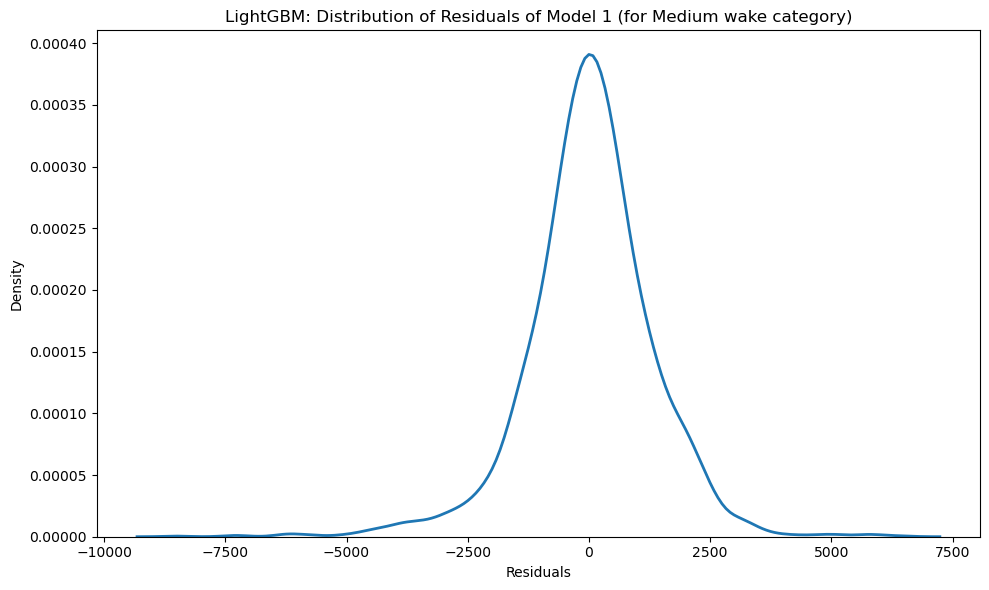

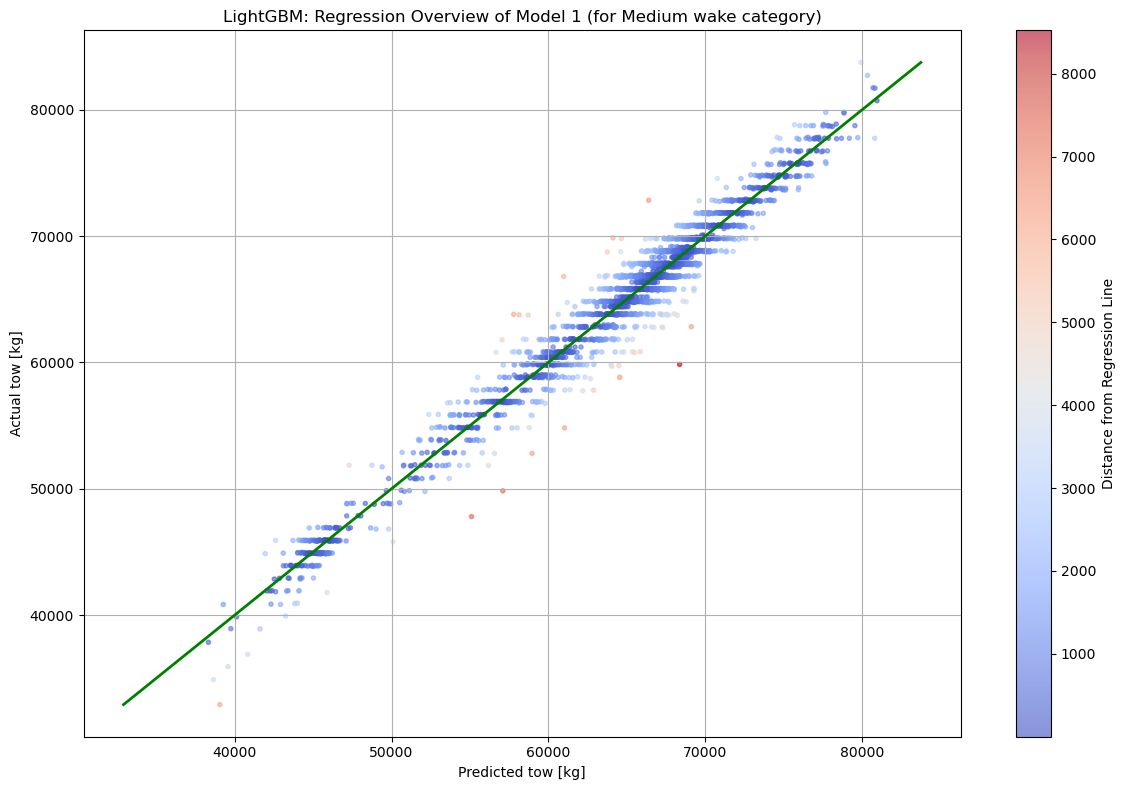

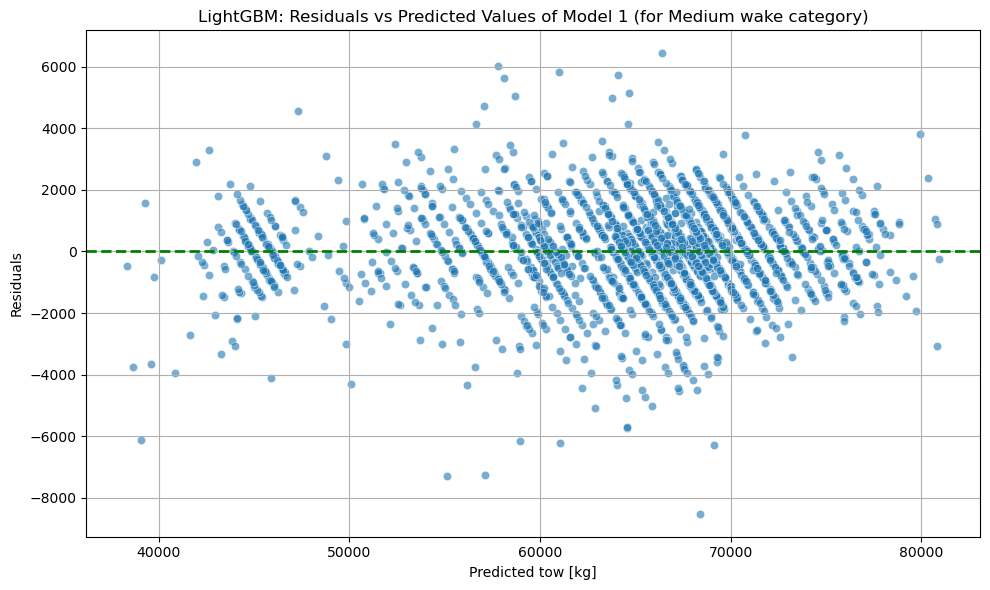

In [22]:
residuals = y_test - y_pred

title1 = "LightGBM: Distribution of Residuals of Model 1 (for Medium wake category)"
title2 = "LightGBM: Regression Overview of Model 1 (for Medium wake category)"
title3 = "LightGBM: Residuals vs Predicted Values of Model 1 (for Medium wake category)"

path1 = "../reports/figures/m1/M_wake/lightgbm_residuals_distribution.png"
path2 = "../reports/figures/m1/M_wake/lightgbm_scatter.png"
path3 = "../reports/figures/m1/M_wake/lightgbm_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### Model 1 Heavy Wake

In [23]:
X_train, X_test, y_train, y_test = preprocess_lightgbm(data_m1_H)

In [24]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'objective': 'regression',
        'metric': 'rmse',
        'n_jobs': -1,
        'device': 'cpu',
        'verbosity': -1,
        'random_state': 42
    }
    
    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
    test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_variables, free_raw_data=False)

    model = lgb.train(
        params,
        train_data,
        valid_sets=[test_data],
        valid_names=['valid'],
        num_boost_round=10_000,
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(period=0),
        ]
    )

    trial.set_user_attr('best_iteration', model.best_iteration)
    
    return model.best_score['valid']['rmse']

In [25]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=None)

print(f"Best trial number: {study.best_trial.number}")
print(f"Best RMSE: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

[I 2025-05-25 16:42:54,828] A new study created in memory with name: no-name-7f70f283-b419-4380-b7ef-d3eae0c8c06c


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[998]	valid's rmse: 5910.53


[I 2025-05-25 16:43:05,270] Trial 0 finished with value: 5910.528818809028 and parameters: {'learning_rate': 0.026736300503098373, 'num_leaves': 131, 'max_depth': 12, 'min_child_weight': 10, 'min_data_in_leaf': 16, 'reg_alpha': 0.0011132772728110767, 'reg_lambda': 0.05521364905898235, 'colsample_bytree': 0.8479009184123047, 'subsample': 0.9834224582000319}. Best is trial 0 with value: 5910.528818809028.


Training until validation scores don't improve for 50 rounds


[I 2025-05-25 16:43:07,201] Trial 1 finished with value: 6203.263679377385 and parameters: {'learning_rate': 0.0364213659783891, 'num_leaves': 136, 'max_depth': 7, 'min_child_weight': 1, 'min_data_in_leaf': 98, 'reg_alpha': 0.011367592375741933, 'reg_lambda': 0.6046400657404813, 'colsample_bytree': 0.7196971757546259, 'subsample': 0.9437120905576842}. Best is trial 0 with value: 5910.528818809028.


...

Early stopping, best iteration is:
[903]	valid's rmse: 5676.26
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[659]	valid's rmse: 5721.32


[I 2025-05-25 16:46:12,390] Trial 48 finished with value: 5721.317972146101 and parameters: {'learning_rate': 0.029698113242458732, 'num_leaves': 118, 'max_depth': 13, 'min_child_weight': 5, 'min_data_in_leaf': 31, 'reg_alpha': 0.0013754967948330036, 'reg_lambda': 0.004411664869527603, 'colsample_bytree': 0.4284640509775587, 'subsample': 0.935508453404543}. Best is trial 34 with value: 5570.402327411154.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1864]	valid's rmse: 5601.58


[I 2025-05-25 16:46:21,622] Trial 49 finished with value: 5601.578186875123 and parameters: {'learning_rate': 0.022668153672509562, 'num_leaves': 137, 'max_depth': 14, 'min_child_weight': 9, 'min_data_in_leaf': 24, 'reg_alpha': 3.1418731764745877, 'reg_lambda': 0.24494201207243213, 'colsample_bytree': 0.7113848820028233, 'subsample': 0.7967519955003765}. Best is trial 34 with value: 5570.402327411154.


Best trial number: 34
Best RMSE: 5570.4023
Best hyperparameters:
  learning_rate: 0.02658229421575557
  num_leaves: 142
  max_depth: 13
  min_child_weight: 5
  min_data_in_leaf: 23
  reg_alpha: 9.701918826889248
  reg_lambda: 0.007638360534758473
  colsample_bytree: 0.5309303142363703
  subsample: 0.9273288338766195


In [26]:
best_params = {
    **study.best_trial.params,
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1
}

train_data_full = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables)

final_model = lgb.train(
    best_params,
    train_data_full,
    num_boost_round=study.best_trial.user_attrs.get('best_iteration', 1000),  # fallback if not tracked
)

In [27]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 3909.30
Root Mean Squared Error: 5570.40
R^2 Score: 0.9255


In [28]:
with open('../models/LightGBM_m1_H.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

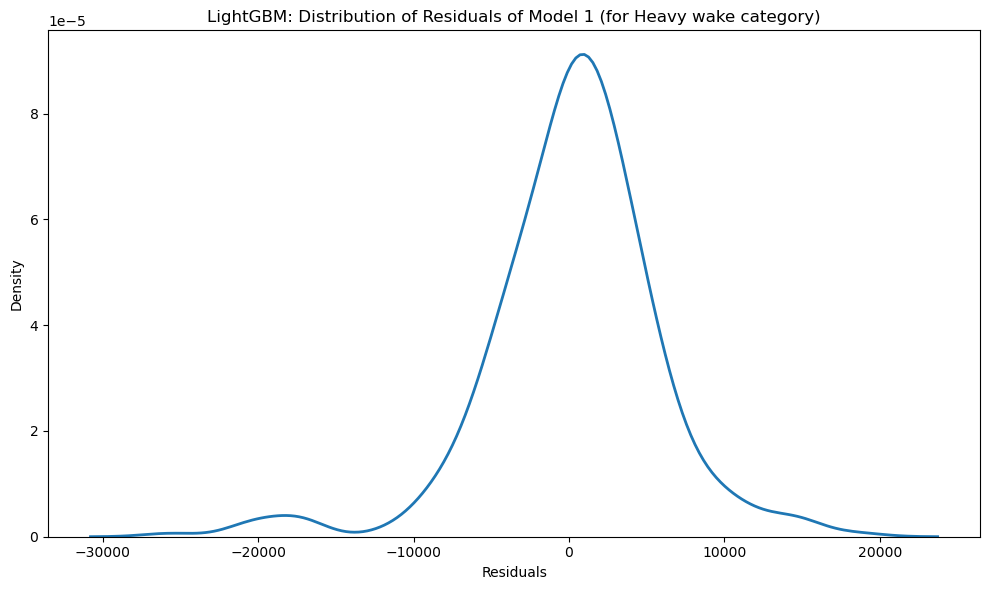

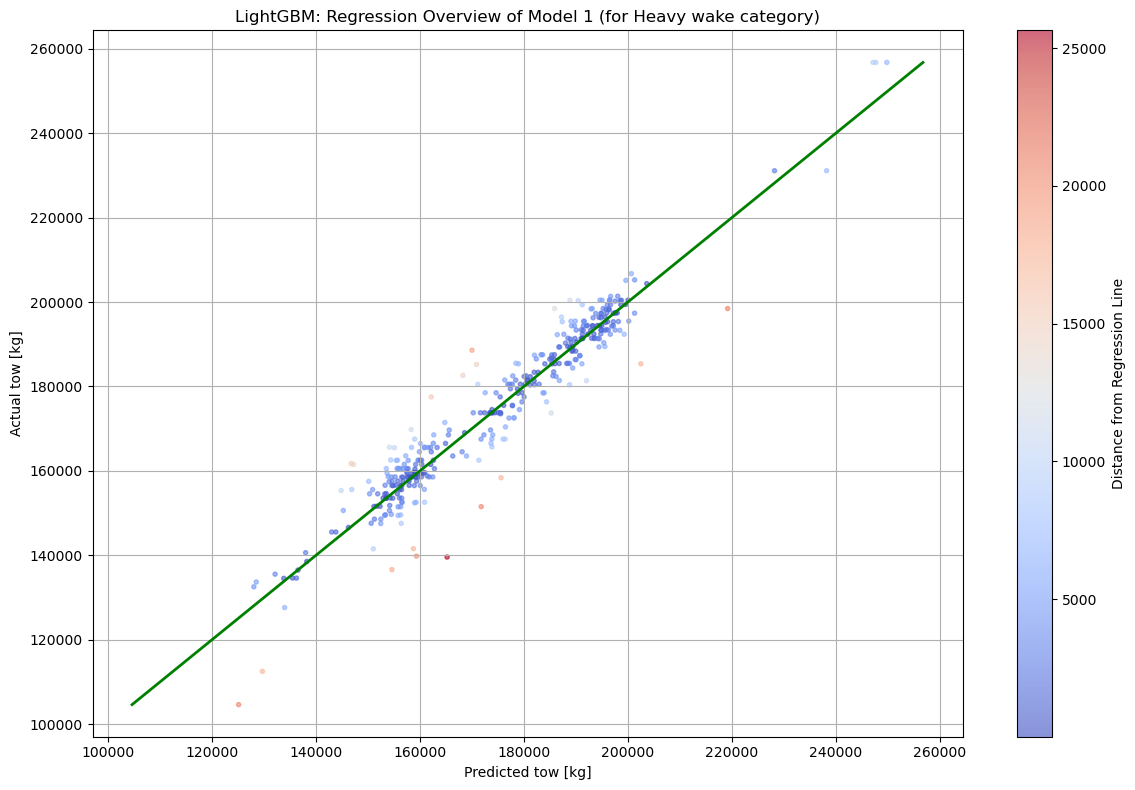

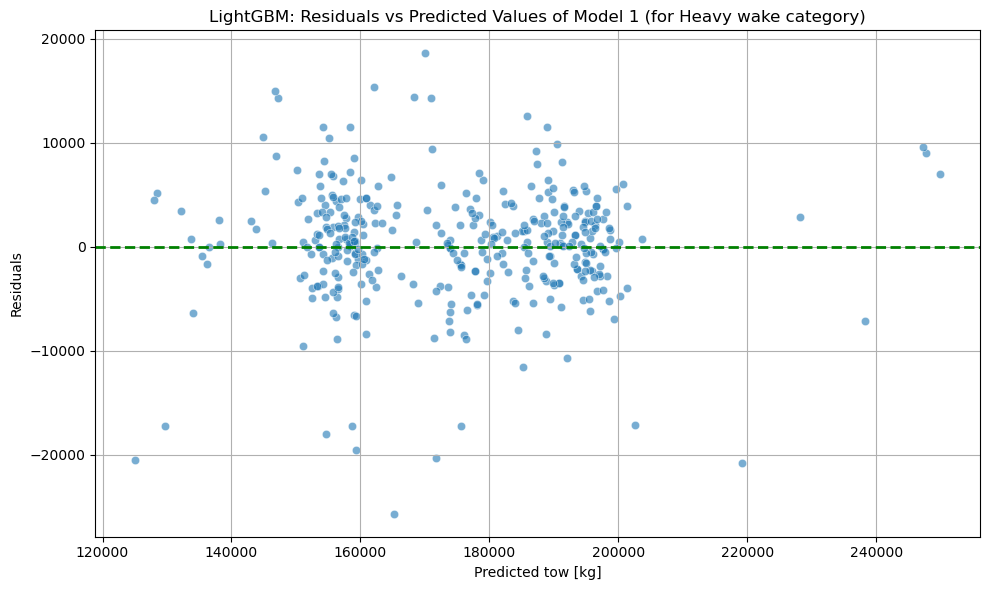

In [29]:
residuals = y_test - y_pred

title1 = "LightGBM: Distribution of Residuals of Model 1 (for Heavy wake category)"
title2 = "LightGBM: Regression Overview of Model 1 (for Heavy wake category)"
title3 = "LightGBM: Residuals vs Predicted Values of Model 1 (for Heavy wake category)"

path1 = "../reports/figures/m1/H_wake/lightgbm_residuals_distribution.png"
path2 = "../reports/figures/m1/H_wake/lightgbm_scatter.png"
path3 = "../reports/figures/m1/H_wake/lightgbm_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### Model 2 Medium Wake

In [30]:
X_train, X_test, y_train, y_test = preprocess_lightgbm(data_m2_M)

In [31]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'objective': 'regression',
        'metric': 'rmse',
        'n_jobs': -1,
        'device': 'cpu',
        'verbosity': -1,
        'random_state': 42
    }
    
    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
    test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_variables, free_raw_data=False)

    model = lgb.train(
        params,
        train_data,
        valid_sets=[test_data],
        valid_names=['valid'],
        num_boost_round=10_000,
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(period=0),
        ]
    )

    trial.set_user_attr('best_iteration', model.best_iteration)
    
    return model.best_score['valid']['rmse']

In [32]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=None)

print(f"Best trial number: {study.best_trial.number}")
print(f"Best RMSE: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

[I 2025-05-25 16:50:19,400] A new study created in memory with name: no-name-08bff929-c0d6-44ec-9a6c-90c0905522be


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1359]	valid's rmse: 1723.56


[I 2025-05-25 16:50:35,723] Trial 0 finished with value: 1723.5571726502887 and parameters: {'learning_rate': 0.022140337765352926, 'num_leaves': 139, 'max_depth': 15, 'min_child_weight': 6, 'min_data_in_leaf': 78, 'reg_alpha': 0.11840406325387158, 'reg_lambda': 0.0014596031626852857, 'colsample_bytree': 0.6335873650470338, 'subsample': 0.9625532699354257}. Best is trial 0 with value: 1723.5571726502887.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3958]	valid's rmse: 1838.89


[I 2025-05-25 16:50:46,771] Trial 1 finished with value: 1838.8878860656098 and parameters: {'learning_rate': 0.03266681293007039, 'num_leaves': 35, 'max_depth': 3, 'min_child_weight': 9, 'min_data_in_leaf': 76, 'reg_alpha': 0.01928272552793607, 'reg_lambda': 0.287689077143014, 'colsample_bytree': 0.7917523796217789, 'subsample': 0.8720589990506924}. Best is trial 0 with value: 1723.5571726502887.


...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[773]	valid's rmse: 1712.45


[I 2025-05-25 17:05:38,627] Trial 48 finished with value: 1712.4462435307983 and parameters: {'learning_rate': 0.03407179505105313, 'num_leaves': 135, 'max_depth': 10, 'min_child_weight': 7, 'min_data_in_leaf': 24, 'reg_alpha': 0.010750273495852275, 'reg_lambda': 0.0011843804982383057, 'colsample_bytree': 0.5827375396008901, 'subsample': 0.6287176179808948}. Best is trial 44 with value: 1690.0300309960078.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1273]	valid's rmse: 1714.89


[I 2025-05-25 17:05:55,647] Trial 49 finished with value: 1714.8938179363004 and parameters: {'learning_rate': 0.02124215820429258, 'num_leaves': 142, 'max_depth': 11, 'min_child_weight': 9, 'min_data_in_leaf': 18, 'reg_alpha': 0.01876580296185235, 'reg_lambda': 9.94769648257238, 'colsample_bytree': 0.49270235585689537, 'subsample': 0.5379989193616376}. Best is trial 44 with value: 1690.0300309960078.


Best trial number: 44
Best RMSE: 1690.0300
Best hyperparameters:
  learning_rate: 0.031085555607191236
  num_leaves: 142
  max_depth: 13
  min_child_weight: 8
  min_data_in_leaf: 15
  reg_alpha: 0.07659243281387648
  reg_lambda: 2.96645655878517
  colsample_bytree: 0.45303212429029394
  subsample: 0.5347989080593569


In [33]:
best_params = {
    **study.best_trial.params,
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1
}

train_data_full = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables)

final_model = lgb.train(
    best_params,
    train_data_full,
    num_boost_round=study.best_trial.user_attrs.get('best_iteration', 1000),  # fallback if not tracked
)

In [34]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 1115.57
Root Mean Squared Error: 1690.03
R^2 Score: 0.9570


In [35]:
with open('../models/LightGBM_m2_M.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

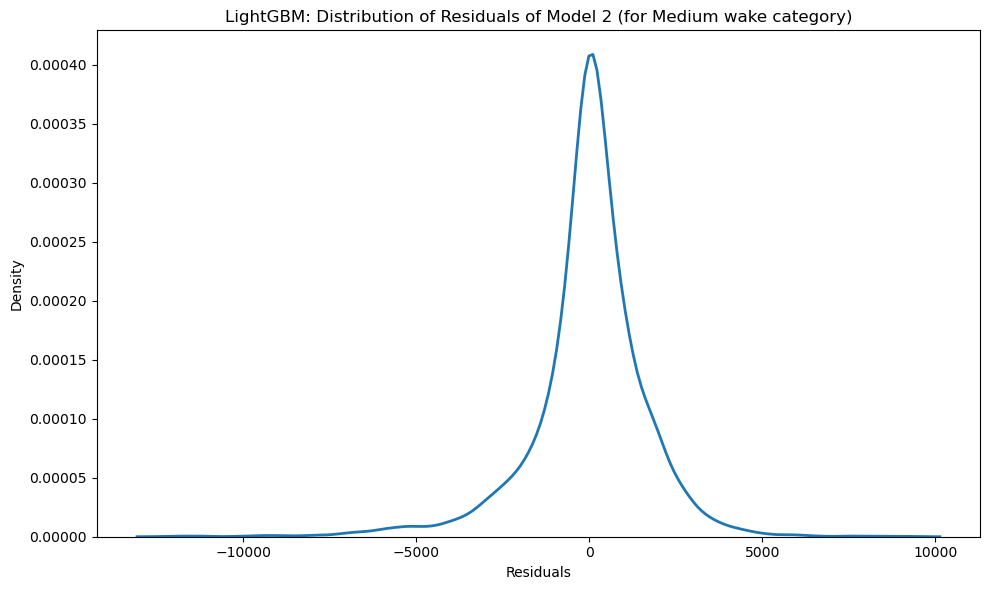

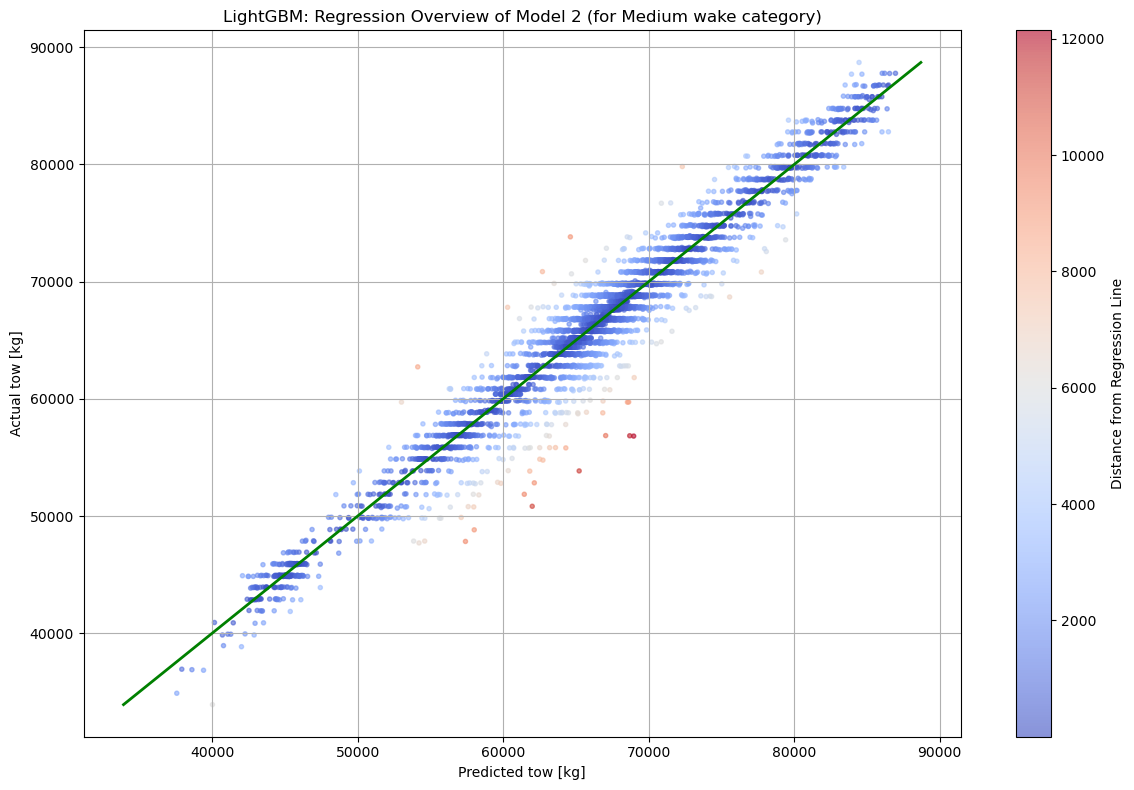

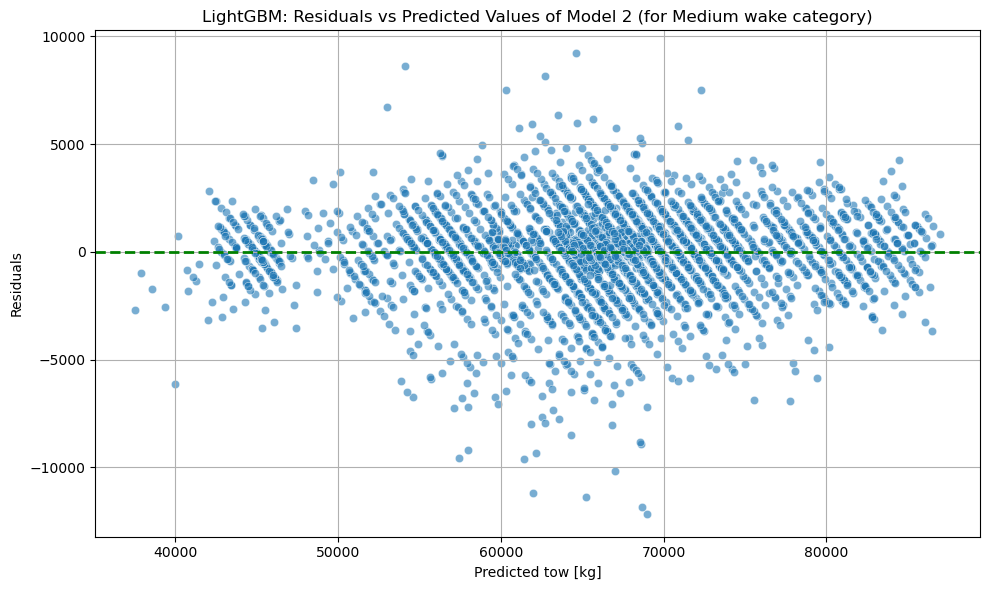

In [36]:
residuals = y_test - y_pred

title1 = "LightGBM: Distribution of Residuals of Model 2 (for Medium wake category)"
title2 = "LightGBM: Regression Overview of Model 2 (for Medium wake category)"
title3 = "LightGBM: Residuals vs Predicted Values of Model 2 (for Medium wake category)"

path1 = "../reports/figures/m2/M_wake/lightgbm_residuals_distribution.png"
path2 = "../reports/figures/m2/M_wake/lightgbm_scatter.png"
path3 = "../reports/figures/m2/M_wake/lightgbm_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### Model 2 Heavy Wake

In [37]:
X_train, X_test, y_train, y_test = preprocess_lightgbm(data_m2_H)

In [38]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'objective': 'regression',
        'metric': 'rmse',
        'n_jobs': -1,
        'device': 'cpu',
        'verbosity': -1,
        'random_state': 42
    }
    
    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
    test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_variables, free_raw_data=False)

    model = lgb.train(
        params,
        train_data,
        valid_sets=[test_data],
        valid_names=['valid'],
        num_boost_round=10_000,
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(period=0),
        ]
    )

    trial.set_user_attr('best_iteration', model.best_iteration)
    
    return model.best_score['valid']['rmse']

In [39]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=None)

print(f"Best trial number: {study.best_trial.number}")
print(f"Best RMSE: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

[I 2025-05-25 17:11:50,655] A new study created in memory with name: no-name-9645650f-14c8-41cc-bfb6-eff50bf611f9


Training until validation scores don't improve for 50 rounds


[I 2025-05-25 17:11:51,639] Trial 0 finished with value: 5675.574383974778 and parameters: {'learning_rate': 0.07599225877043769, 'num_leaves': 40, 'max_depth': 6, 'min_child_weight': 6, 'min_data_in_leaf': 43, 'reg_alpha': 0.0011355783144071125, 'reg_lambda': 0.0016633772197127592, 'colsample_bytree': 0.7256154852700484, 'subsample': 0.6549348582044627}. Best is trial 0 with value: 5675.574383974778.


Early stopping, best iteration is:
[494]	valid's rmse: 5675.57
Training until validation scores don't improve for 50 rounds


[I 2025-05-25 17:11:53,458] Trial 1 finished with value: 5750.669775500596 and parameters: {'learning_rate': 0.029190861438087374, 'num_leaves': 90, 'max_depth': 6, 'min_child_weight': 2, 'min_data_in_leaf': 89, 'reg_alpha': 0.00938992117144391, 'reg_lambda': 0.0029688273070081965, 'colsample_bytree': 0.8941738514346786, 'subsample': 0.618215264882098}. Best is trial 0 with value: 5675.574383974778.


...

Training until validation scores don't improve for 50 rounds


[I 2025-05-25 17:14:42,264] Trial 48 finished with value: 5838.495621324674 and parameters: {'learning_rate': 0.04491178172115858, 'num_leaves': 49, 'max_depth': 10, 'min_child_weight': 7, 'min_data_in_leaf': 28, 'reg_alpha': 1.008712402417985, 'reg_lambda': 0.031655029506842174, 'colsample_bytree': 0.6177303416641351, 'subsample': 0.5800287095127221}. Best is trial 19 with value: 5474.836322846601.


Early stopping, best iteration is:
[380]	valid's rmse: 5838.5
Training until validation scores don't improve for 50 rounds


[I 2025-05-25 17:14:44,529] Trial 49 finished with value: 5527.116093587361 and parameters: {'learning_rate': 0.026447886752364796, 'num_leaves': 25, 'max_depth': 13, 'min_child_weight': 4, 'min_data_in_leaf': 74, 'reg_alpha': 2.0555314001887455, 'reg_lambda': 0.01083149116429566, 'colsample_bytree': 0.5600530898045112, 'subsample': 0.7053661713745195}. Best is trial 19 with value: 5474.836322846601.


Early stopping, best iteration is:
[814]	valid's rmse: 5527.12
Best trial number: 19
Best RMSE: 5474.8363
Best hyperparameters:
  learning_rate: 0.022794324236287525
  num_leaves: 103
  max_depth: 11
  min_child_weight: 5
  min_data_in_leaf: 34
  reg_alpha: 0.3657385937529835
  reg_lambda: 0.06281068692729679
  colsample_bytree: 0.6012635834381729
  subsample: 0.814294441357693


In [40]:
best_params = {
    **study.best_trial.params,
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1
}

train_data_full = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables)

final_model = lgb.train(
    best_params,
    train_data_full,
    num_boost_round=study.best_trial.user_attrs.get('best_iteration', 1000),  # fallback if not tracked
)

In [41]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 3964.35
Root Mean Squared Error: 5474.84
R^2 Score: 0.9628


In [42]:
with open('../models/LightGBM_m2_H.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

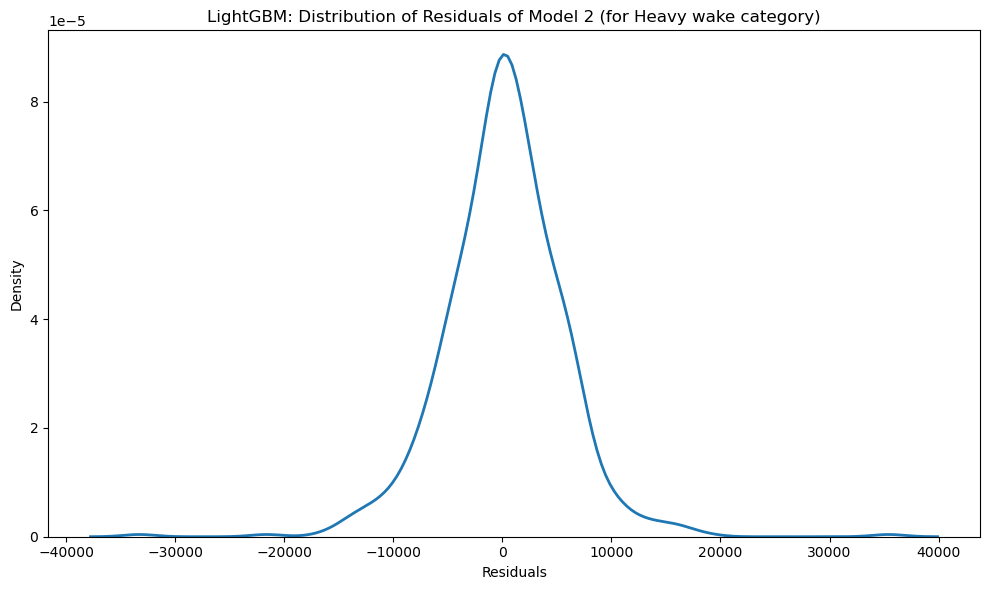

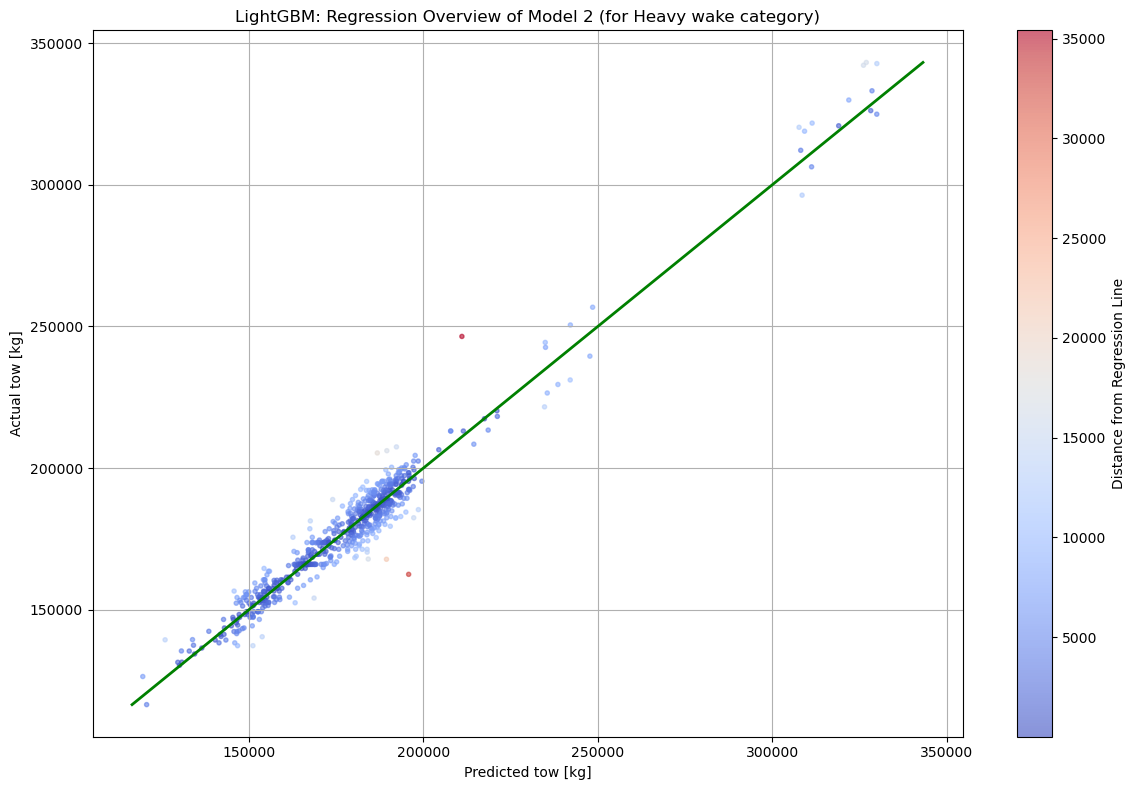

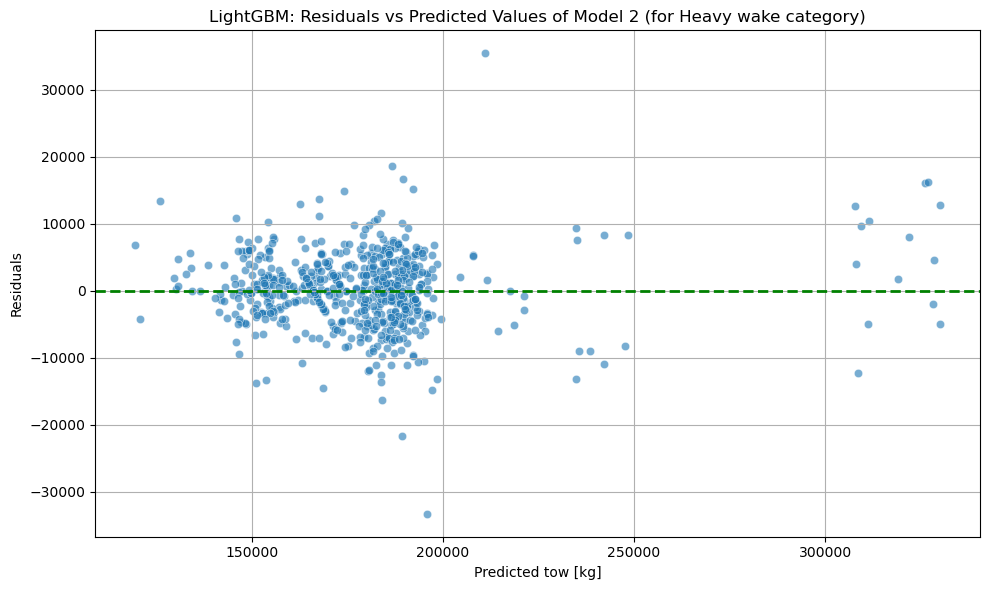

In [43]:
residuals = y_test - y_pred

title1 = "LightGBM: Distribution of Residuals of Model 2 (for Heavy wake category)"
title2 = "LightGBM: Regression Overview of Model 2 (for Heavy wake category)"
title3 = "LightGBM: Residuals vs Predicted Values of Model 2 (for Heavy wake category)"

path1 = "../reports/figures/m2/H_wake/lightgbm_residuals_distribution.png"
path2 = "../reports/figures/m2/H_wake/lightgbm_scatter.png"
path3 = "../reports/figures/m2/H_wake/lightgbm_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### m1 + m2 (for M wake category)

In [44]:
X_train, X_test, y_train, y_test = preprocess_lightgbm(data_M)

In [45]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'objective': 'regression',
        'metric': 'rmse',
        'n_jobs': -1,
        'device': 'cpu',
        'verbosity': -1,
        'random_state': 42
    }
    
    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
    test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_variables, free_raw_data=False)

    model = lgb.train(
        params,
        train_data,
        valid_sets=[test_data],
        valid_names=['valid'],
        num_boost_round=10_000,
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(period=0),
        ]
    )

    trial.set_user_attr('best_iteration', model.best_iteration)
    
    return model.best_score['valid']['rmse']

In [46]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=None)

print(f"Best trial number: {study.best_trial.number}")
print(f"Best RMSE: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

[I 2025-05-25 17:20:21,833] A new study created in memory with name: no-name-578a1800-bff6-44fb-927a-6a81a08bfc9c


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2725]	valid's rmse: 1572.34


[I 2025-05-25 17:20:55,629] Trial 0 finished with value: 1572.3396242154058 and parameters: {'learning_rate': 0.021819520728877818, 'num_leaves': 79, 'max_depth': 12, 'min_child_weight': 8, 'min_data_in_leaf': 47, 'reg_alpha': 0.031013090157652683, 'reg_lambda': 0.02277111816440406, 'colsample_bytree': 0.8108930929403388, 'subsample': 0.822155337818054}. Best is trial 0 with value: 1572.3396242154058.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2571]	valid's rmse: 1590.43


[I 2025-05-25 17:21:19,459] Trial 1 finished with value: 1590.4291553662101 and parameters: {'learning_rate': 0.04091457154153129, 'num_leaves': 42, 'max_depth': 7, 'min_child_weight': 3, 'min_data_in_leaf': 89, 'reg_alpha': 0.7872337806884503, 'reg_lambda': 0.0010567646590745956, 'colsample_bytree': 0.5962982081390895, 'subsample': 0.5001460962566933}. Best is trial 0 with value: 1572.3396242154058.


...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1372]	valid's rmse: 1570.56


[I 2025-05-25 17:44:24,904] Trial 48 finished with value: 1570.5632544454122 and parameters: {'learning_rate': 0.05132068149360946, 'num_leaves': 47, 'max_depth': 12, 'min_child_weight': 2, 'min_data_in_leaf': 39, 'reg_alpha': 1.3251544897420524, 'reg_lambda': 0.018537188431882286, 'colsample_bytree': 0.6829421128579798, 'subsample': 0.8913604175927771}. Best is trial 25 with value: 1556.2696858115646.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3366]	valid's rmse: 1564.12


[I 2025-05-25 17:45:02,839] Trial 49 finished with value: 1564.1227237760872 and parameters: {'learning_rate': 0.01246090762467515, 'num_leaves': 136, 'max_depth': 11, 'min_child_weight': 3, 'min_data_in_leaf': 25, 'reg_alpha': 4.733496592186665, 'reg_lambda': 0.10789543888837706, 'colsample_bytree': 0.6267105081831846, 'subsample': 0.6500382469469796}. Best is trial 25 with value: 1556.2696858115646.


Best trial number: 25
Best RMSE: 1556.2697
Best hyperparameters:
  learning_rate: 0.013327281352774814
  num_leaves: 61
  max_depth: 11
  min_child_weight: 3
  min_data_in_leaf: 16
  reg_alpha: 0.5681228909514936
  reg_lambda: 0.01266196085868397
  colsample_bytree: 0.5927231878176726
  subsample: 0.8092260037927674


In [47]:
best_params = {
    **study.best_trial.params,
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1
}

train_data_full = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables)

final_model = lgb.train(
    best_params,
    train_data_full,
    num_boost_round=study.best_trial.user_attrs.get('best_iteration', 1000),  # fallback if not tracked
)

In [51]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 1035.49
Root Mean Squared Error: 1556.27
R^2 Score: 0.9614


In [52]:
with open('../models/LightGBM_m1+m2_M.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

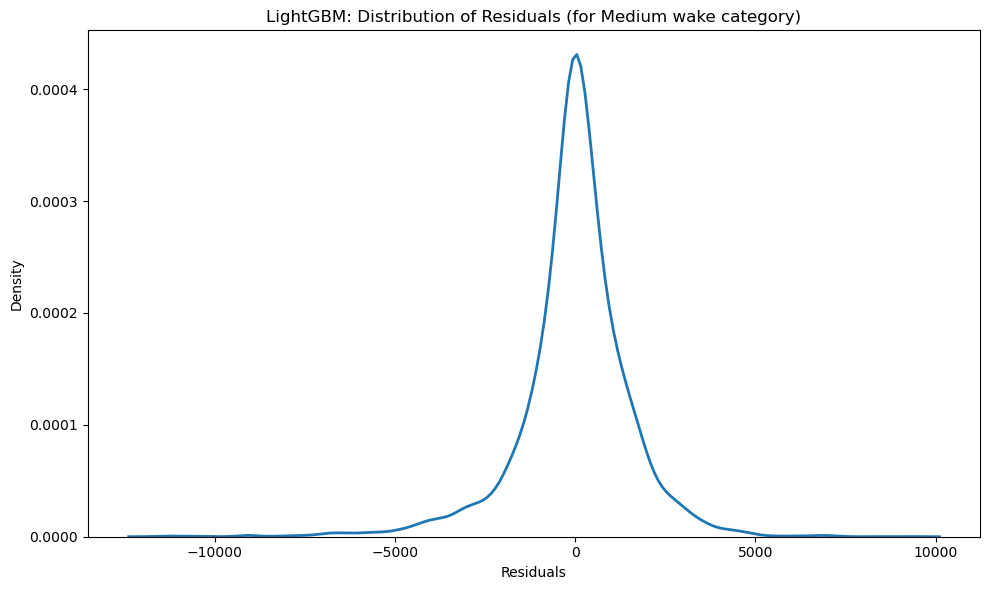

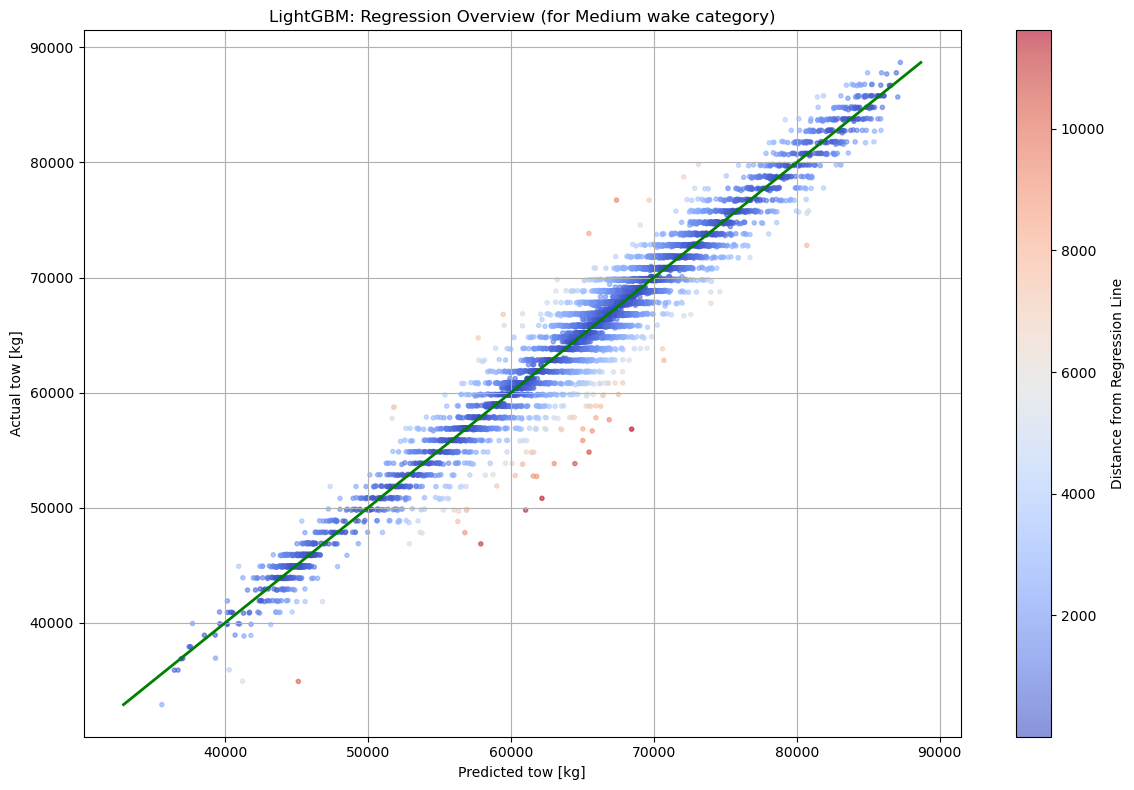

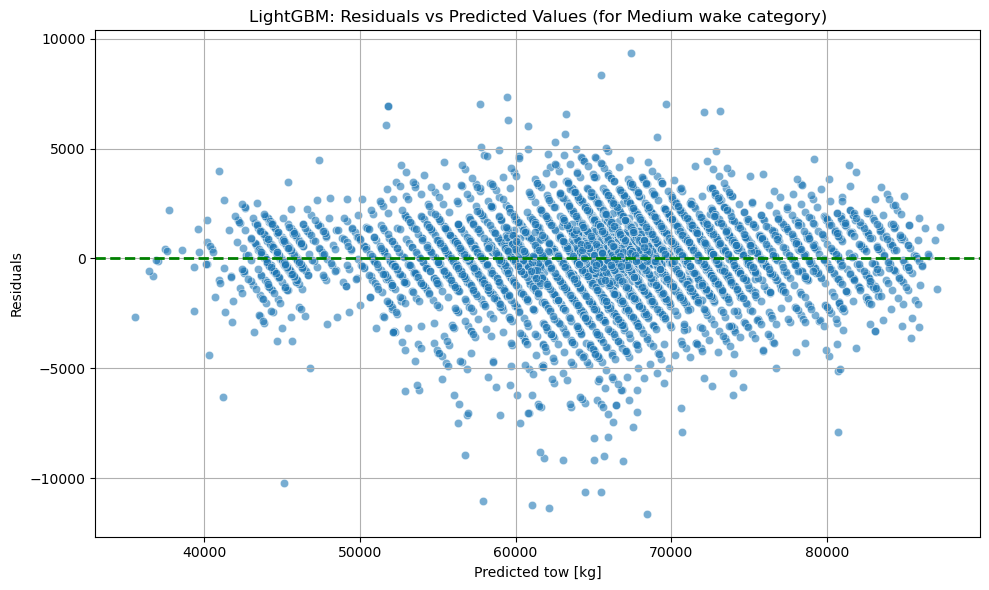

In [53]:
residuals = y_test - y_pred

title1 = "LightGBM: Distribution of Residuals (for Medium wake category)"
title2 = "LightGBM: Regression Overview (for Medium wake category)"
title3 = "LightGBM: Residuals vs Predicted Values (for Medium wake category)"

path1 = "../reports/figures/M/lightgbm_residuals_distribution.png"
path2 = "../reports/figures/M/lightgbm_scatter.png"
path3 = "../reports/figures/M/lightgbm_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### m1 + m2 (for H wake category)

In [54]:
X_train, X_test, y_train, y_test = preprocess_lightgbm(data_H)

In [55]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'objective': 'regression',
        'metric': 'rmse',
        'n_jobs': -1,
        'device': 'cpu',
        'verbosity': -1,
        'random_state': 42
    }
    
    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
    test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_variables, free_raw_data=False)

    model = lgb.train(
        params,
        train_data,
        valid_sets=[test_data],
        valid_names=['valid'],
        num_boost_round=10_000,
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(period=0),
        ]
    )

    trial.set_user_attr('best_iteration', model.best_iteration)
    
    return model.best_score['valid']['rmse']

In [56]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=None)

print(f"Best trial number: {study.best_trial.number}")
print(f"Best RMSE: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

[I 2025-05-25 18:06:22,193] A new study created in memory with name: no-name-63dc800f-57c1-4ee0-b3d1-9c1ef73f6e5e


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2482]	valid's rmse: 5222.77


[I 2025-05-25 18:06:30,515] Trial 0 finished with value: 5222.76922802293 and parameters: {'learning_rate': 0.01229975758175079, 'num_leaves': 72, 'max_depth': 10, 'min_child_weight': 9, 'min_data_in_leaf': 50, 'reg_alpha': 0.0017824476609608817, 'reg_lambda': 0.0030641732093061274, 'colsample_bytree': 0.8556119740955208, 'subsample': 0.6927454921379932}. Best is trial 0 with value: 5222.76922802293.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3840]	valid's rmse: 5314.56


[I 2025-05-25 18:06:34,847] Trial 1 finished with value: 5314.560639104251 and parameters: {'learning_rate': 0.01314437457632744, 'num_leaves': 109, 'max_depth': 3, 'min_child_weight': 4, 'min_data_in_leaf': 18, 'reg_alpha': 0.9751263666248684, 'reg_lambda': 0.001844263233810413, 'colsample_bytree': 0.7551666553915264, 'subsample': 0.829689105250714}. Best is trial 0 with value: 5222.76922802293.


...

Early stopping, best iteration is:
[1139]	valid's rmse: 5113.98
Training until validation scores don't improve for 50 rounds


[I 2025-05-25 18:08:59,624] Trial 48 finished with value: 5440.682049989292 and parameters: {'learning_rate': 0.06104722734985279, 'num_leaves': 90, 'max_depth': 5, 'min_child_weight': 10, 'min_data_in_leaf': 100, 'reg_alpha': 0.2299533168831105, 'reg_lambda': 2.392975385868247, 'colsample_bytree': 0.424166568558296, 'subsample': 0.5616025390880984}. Best is trial 14 with value: 5012.890835975897.


Early stopping, best iteration is:
[1060]	valid's rmse: 5440.68
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1401]	valid's rmse: 5195.94


[I 2025-05-25 18:09:03,024] Trial 49 finished with value: 5195.944911172467 and parameters: {'learning_rate': 0.02854312483622199, 'num_leaves': 122, 'max_depth': 6, 'min_child_weight': 4, 'min_data_in_leaf': 37, 'reg_alpha': 0.019259721122921788, 'reg_lambda': 0.004570551532680196, 'colsample_bytree': 0.6771494581153272, 'subsample': 0.684548824066713}. Best is trial 14 with value: 5012.890835975897.


Best trial number: 14
Best RMSE: 5012.8908
Best hyperparameters:
  learning_rate: 0.024631011093888332
  num_leaves: 101
  max_depth: 6
  min_child_weight: 2
  min_data_in_leaf: 10
  reg_alpha: 7.7449327998425606
  reg_lambda: 0.32994004706248886
  colsample_bytree: 0.43797629825442935
  subsample: 0.6042486513986006


In [57]:
best_params = {
    **study.best_trial.params,
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1
}

train_data_full = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables)

final_model = lgb.train(
    best_params,
    train_data_full,
    num_boost_round=study.best_trial.user_attrs.get('best_iteration', 1000),  # fallback if not tracked
)

In [58]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 3783.81
Root Mean Squared Error: 5012.89
R^2 Score: 0.9529


In [59]:
with open('../models/LightGBM_m1+m2_H.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

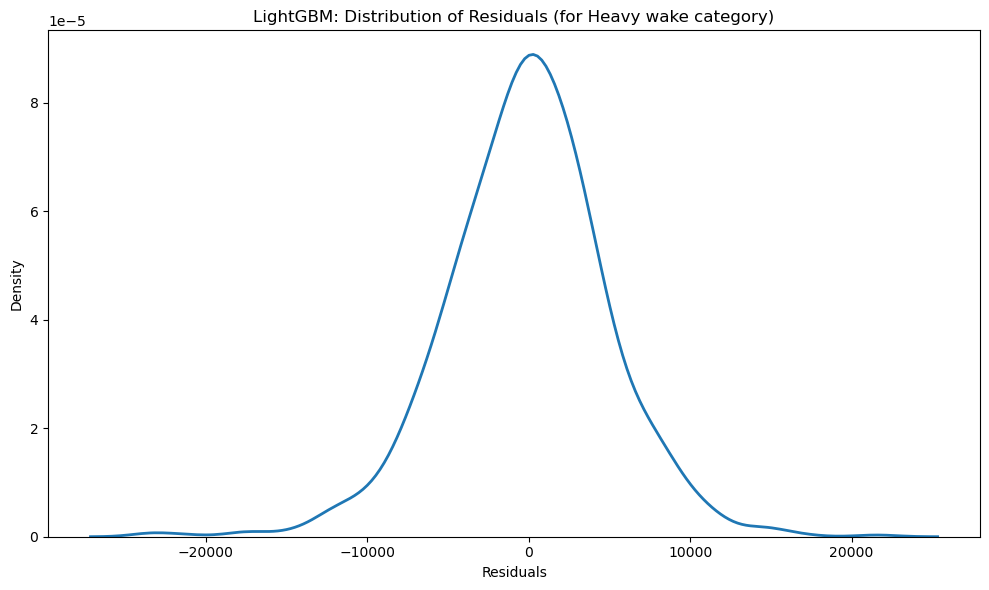

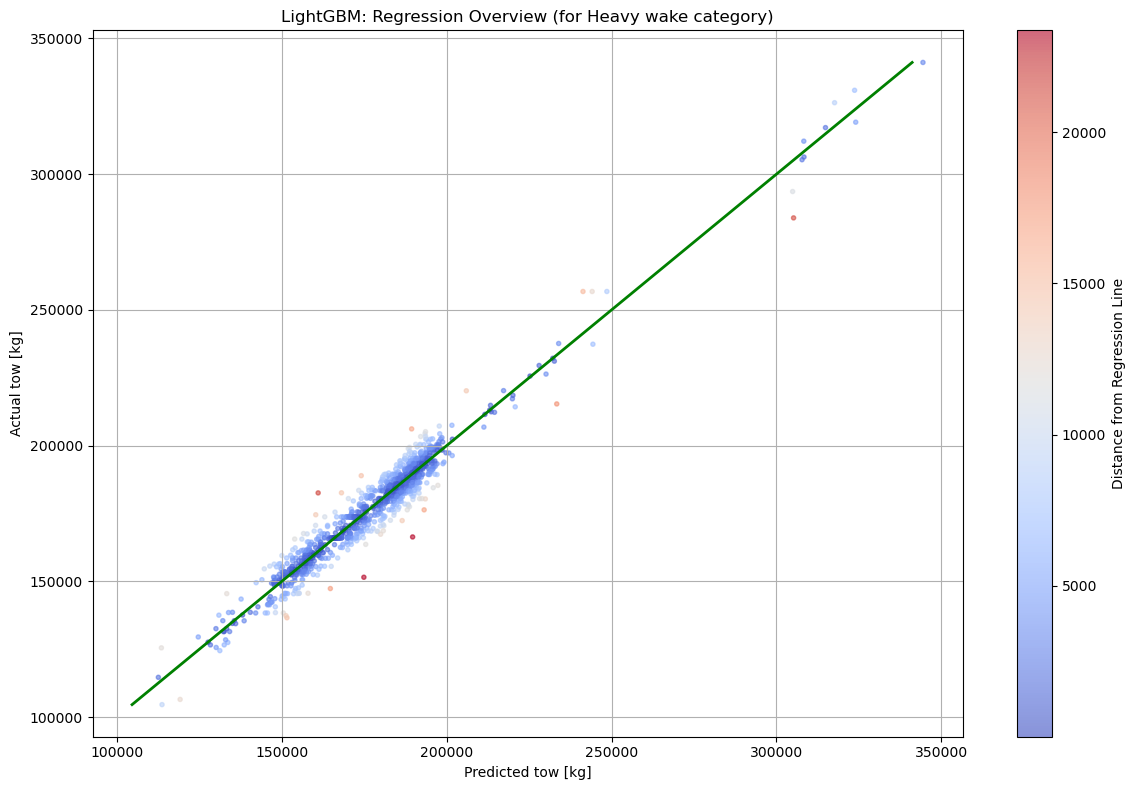

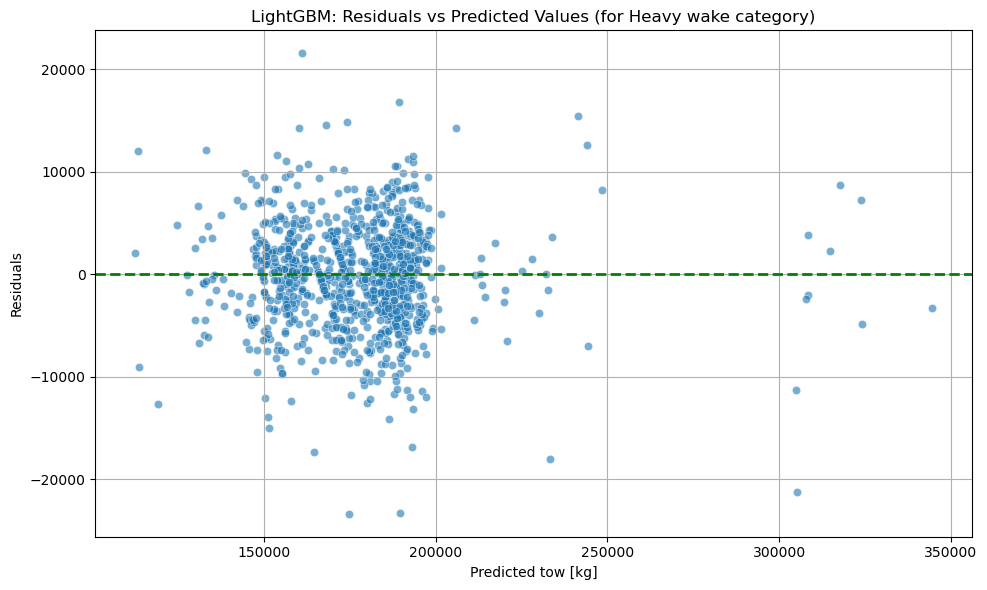

In [60]:
residuals = y_test - y_pred

title1 = "LightGBM: Distribution of Residuals (for Heavy wake category)"
title2 = "LightGBM: Regression Overview (for Heavy wake category)"
title3 = "LightGBM: Residuals vs Predicted Values (for Heavy wake category)"

path1 = "../reports/figures/H/lightgbm_residuals_distribution.png"
path2 = "../reports/figures/H/lightgbm_scatter.png"
path3 = "../reports/figures/H/lightgbm_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)